# Investigate Unassigned & Artifact_Spillover

Follow-up to `analyze_cell_types_from_markers.ipynb`.

Binary thresholds are partly subjective, so large **Unassigned** and **Artifact_Spillover** pools can reflect cutoff choice, incomplete rules, or real artifacts. This notebook profiles which channels drive those labels.

**Companion:** `investigate_unassigned_spillover_umap.ipynb` — same question via UMAP + Leiden clustering in continuous marker space (not threshold selection).

**Plan**
1. **Unassigned marker profiles** (this notebook starts here)
2. Artifact_Spillover by gate / channel (next)

| | Path |
|---|---|
| **In** | `output/celldive_protein_matrix_celltypes.h5ad` |

## 1. Imports & load

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INPUT_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix_celltypes.h5ad"

# Skip nuclear / redundant channels in marker-profile plots
SKIP_MARKERS = {"DAPI", "DAPI2"}

adata = ad.read_h5ad(INPUT_H5AD)
assert "cell_type" in adata.obs, "Run analyze_cell_types_from_markers.ipynb first"
assert "binary" in adata.layers, "Expected layers['binary']"

markers = [m for m in adata.var_names if m not in SKIP_MARKERS]
marker_idx = [list(adata.var_names).index(m) for m in markers]

X_bin = np.asarray(adata.layers["binary"][:, marker_idx], dtype=np.uint8)
X_cont = np.asarray(adata.X[:, marker_idx], dtype=np.float32)

print(f"Loaded: {INPUT_H5AD}")
print(f"Cells: {adata.n_obs:,}  |  markers used: {len(markers)}")
print(adata.obs["cell_type"].value_counts().to_string())

Loaded: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix_celltypes.h5ad
Cells: 926,006  |  markers used: 21
cell_type
Myofibroblast         261073
Artifact_Spillover    146584
Unassigned            106703
Collagen_stroma        95916
Mesenchymal            68725
Epithelial_EPCAM       61775
Endothelial            53082
Fibroblast             48012
CD8_T                  34340
Epithelial             15686
B_cell                  8394
CD4_T                   7244
T_cell                  7052
Other_immune            4001
Macrophage              2217
Dendritic               2094
Monocyte                1977
M2_like                  710
NK_cell                  421


## 2. Define groups

- **Unassigned** — passed QC (`is_clean`) but matched no phenotype rule
- **Assigned (clean)** — clean cells with a real phenotype label
- **Artifact_Spillover** — reserved for the next section

In [3]:
ct = adata.obs["cell_type"].astype(str)
is_clean = adata.obs["is_clean"].to_numpy()

mask_unassigned = (ct == "Unassigned").to_numpy()
mask_spillover = (ct == "Artifact_Spillover").to_numpy()
mask_assigned = is_clean & ~mask_unassigned

n_un = int(mask_unassigned.sum())
n_as = int(mask_assigned.sum())
n_sp = int(mask_spillover.sum())

print(f"Unassigned          : {n_un:,}  ({100 * n_un / adata.n_obs:.2f} % of all cells)")
print(f"Assigned (clean)    : {n_as:,}  ({100 * n_as / adata.n_obs:.2f} %)")
print(f"Artifact_Spillover  : {n_sp:,}  ({100 * n_sp / adata.n_obs:.2f} %)  [next section]")
print(f"\nUnassigned as % of clean cells: {100 * n_un / is_clean.sum():.2f} %")

Unassigned          : 106,703  (11.52 % of all cells)
Assigned (clean)    : 672,719  (72.65 %)
Artifact_Spillover  : 146,584  (15.83 %)  [next section]

Unassigned as % of clean cells: 13.69 %


## 3. Unassigned — binary positivity rates

Compare fraction positive per marker in Unassigned vs Assigned (clean).

Interpretation guide:
- **Mostly all-zero** → threshold too high, or truly blank / debris-like cells
- **Markers on, but odd combos** → rules incomplete (missing phenotypes)
- **Many weak lineage markers near cutoff** → threshold sensitivity

In [4]:
def positivity_rate(X_bin: np.ndarray, mask: np.ndarray) -> pd.Series:
    return pd.Series(X_bin[mask].mean(axis=0), index=markers, name="frac_positive")


pos_un = positivity_rate(X_bin, mask_unassigned)
pos_as = positivity_rate(X_bin, mask_assigned)

pos_tbl = pd.DataFrame({
    "Unassigned": pos_un,
    "Assigned_clean": pos_as,
    "delta_Unassigned_minus_Assigned": pos_un - pos_as,
})
pos_tbl = pos_tbl.sort_values("Unassigned", ascending=False)

print("Binary positivity rates (fraction of cells positive):")
display(pos_tbl.style.format("{:.3f}").background_gradient(
    subset=["Unassigned", "Assigned_clean"], cmap="YlOrRd", vmin=0, vmax=1
))

Binary positivity rates (fraction of cells positive):


,Unassigned,Assigned_clean,delta_Unassigned_minus_Assigned
CD14,0.449,0.431,0.018
HLADR,0.381,0.367,0.014
CD163,0.194,0.110,0.085
CD8a,0.125,0.280,-0.156
CD68,0.115,0.068,0.047
CD56,0.114,0.231,-0.117
CD3E,0.109,0.190,-0.081
CD38,0.087,0.112,-0.024
CD45RO,0.083,0.104,-0.021
CD11c,0.076,0.064,0.012


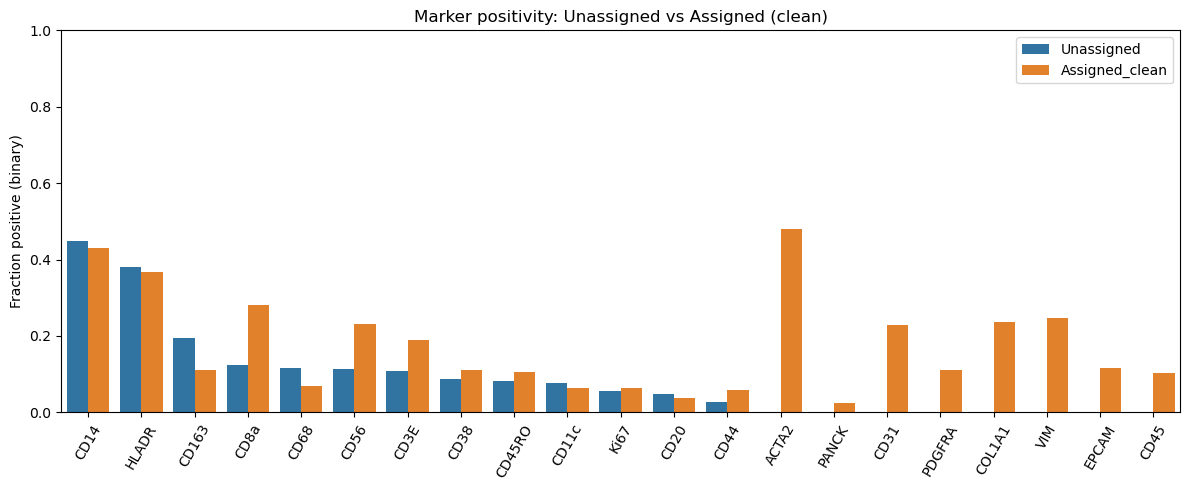

In [5]:
plot_df = pos_tbl[["Unassigned", "Assigned_clean"]].reset_index(names="marker").melt(
    id_vars="marker", var_name="group", value_name="frac_positive"
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_df,
    x="marker",
    y="frac_positive",
    hue="group",
    ax=ax,
    order=pos_tbl.index.tolist(),
)
ax.set_ylabel("Fraction positive (binary)")
ax.set_xlabel("")
ax.set_title("Marker positivity: Unassigned vs Assigned (clean)")
ax.tick_params(axis="x", rotation=60)
ax.set_ylim(0, 1)
ax.legend(title="")
fig.tight_layout()
plt.show()

## 4. How many Unassigned cells are marker-negative?

Count how many phenotype markers are binary-positive per Unassigned cell.
A large spike at 0 means "blank" cells after thresholding.

Markers positive per cell — Unassigned:
0     35191
1     21874
2     14011
3     13008
4     11039
5      6592
6      3143
7      1263
8       423
9       134
10       21
11        4

  zero-positive Unassigned : 35,191  (33.0 %)
  ≥1-positive Unassigned   : 71,512  (67.0 %)

Markers positive per cell — Assigned (clean) mean±std: 3.66 ± 2.33


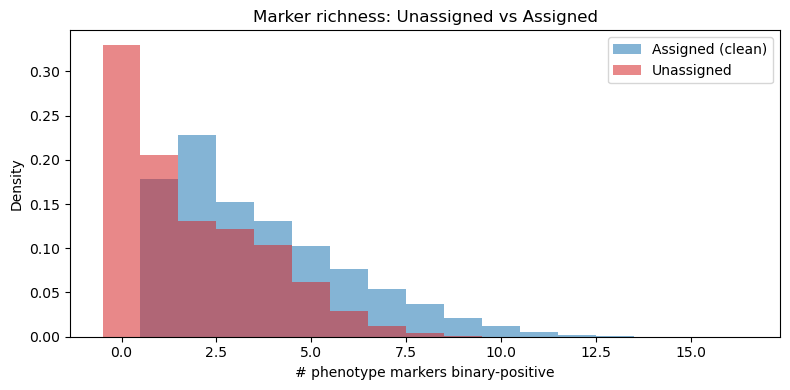

In [6]:
n_pos_un = X_bin[mask_unassigned].sum(axis=1)
n_pos_as = X_bin[mask_assigned].sum(axis=1)

print("Markers positive per cell — Unassigned:")
print(pd.Series(n_pos_un).value_counts().sort_index().to_string())
print(f"\n  zero-positive Unassigned : {(n_pos_un == 0).sum():,}  ({100 * (n_pos_un == 0).mean():.1f} %)")
print(f"  ≥1-positive Unassigned   : {(n_pos_un >= 1).sum():,}  ({100 * (n_pos_un >= 1).mean():.1f} %)")
print(f"\nMarkers positive per cell — Assigned (clean) mean±std: {n_pos_as.mean():.2f} ± {n_pos_as.std():.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, max(n_pos_un.max(), n_pos_as.max()) + 2) - 0.5
ax.hist(n_pos_as, bins=bins, density=True, alpha=0.55, label="Assigned (clean)", color="C0")
ax.hist(n_pos_un, bins=bins, density=True, alpha=0.55, label="Unassigned", color="C3")
ax.set_xlabel("# phenotype markers binary-positive")
ax.set_ylabel("Density")
ax.set_title("Marker richness: Unassigned vs Assigned")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Top binary marker patterns among Unassigned

Which co-expression patterns are most common in Unassigned?
Patterns that look like near-misses of existing rules (e.g. CD45+ alone is already `Other_immune`) help decide whether rules or thresholds need work.

In [7]:
TOP_N_PATTERNS = 25


def pattern_string(row: np.ndarray) -> str:
    on = [m for m, v in zip(markers, row) if v == 1]
    return "+".join(on) if on else "(none)"


patterns = pd.Series(
    [pattern_string(row) for row in X_bin[mask_unassigned]],
    name="pattern",
)
pat_counts = patterns.value_counts().head(TOP_N_PATTERNS).rename("n_cells").to_frame()
pat_counts["pct_of_Unassigned"] = 100 * pat_counts["n_cells"] / n_un

print(f"Top {TOP_N_PATTERNS} binary patterns in Unassigned ({n_un:,} cells):")
display(pat_counts.style.format({"pct_of_Unassigned": "{:.2f}%"}))

Top 25 binary patterns in Unassigned (106,703 cells):


,n_cells,pct_of_Unassigned
pattern,,
(none),35191,32.98%
CD56,7898,7.40%
CD14,5124,4.80%
HLADR+CD163+CD14,4845,4.54%
HLADR+CD14,4766,4.47%
CD68+HLADR+CD163+CD14,3947,3.70%
HLADR,2425,2.27%
CD3E,1498,1.40%
CD68+HLADR+CD163+CD11c+CD14,1461,1.37%


## 6. Continuous intensity: Unassigned vs Assigned

Binary positivity can hide near-threshold signal. Compare log1p continuous intensities
for Unassigned vs Assigned (clean). Large left-shifts support "mostly blank / below cutoff";
similar distributions with different binary rates suggest threshold fragility.

In [8]:
# Mean log1p intensity per marker (group comparison table)
logX = np.log1p(X_cont)

mean_un = pd.Series(logX[mask_unassigned].mean(axis=0), index=markers, name="Unassigned")
mean_as = pd.Series(logX[mask_assigned].mean(axis=0), index=markers, name="Assigned_clean")
mean_tbl = pd.DataFrame({"Unassigned": mean_un, "Assigned_clean": mean_as})
mean_tbl["delta"] = mean_tbl["Unassigned"] - mean_tbl["Assigned_clean"]
mean_tbl = mean_tbl.sort_values("delta")

print("Mean log1p intensity (Unassigned sorted by most depleted vs Assigned):")
display(mean_tbl.style.format("{:.3f}").background_gradient(subset=["delta"], cmap="RdBu_r"))

Mean log1p intensity (Unassigned sorted by most depleted vs Assigned):


,Unassigned,Assigned_clean,delta
CD8a,4.191,5.143,-0.953
ACTA2,5.048,5.952,-0.904
CD31,1.962,2.835,-0.873
CD3E,3.700,4.270,-0.570
PANCK,4.866,5.245,-0.380
VIM,6.233,6.609,-0.376
CD44,6.842,7.205,-0.364
CD45,3.760,4.090,-0.330
CD45RO,2.525,2.676,-0.150
COL1A1,7.111,7.245,-0.134


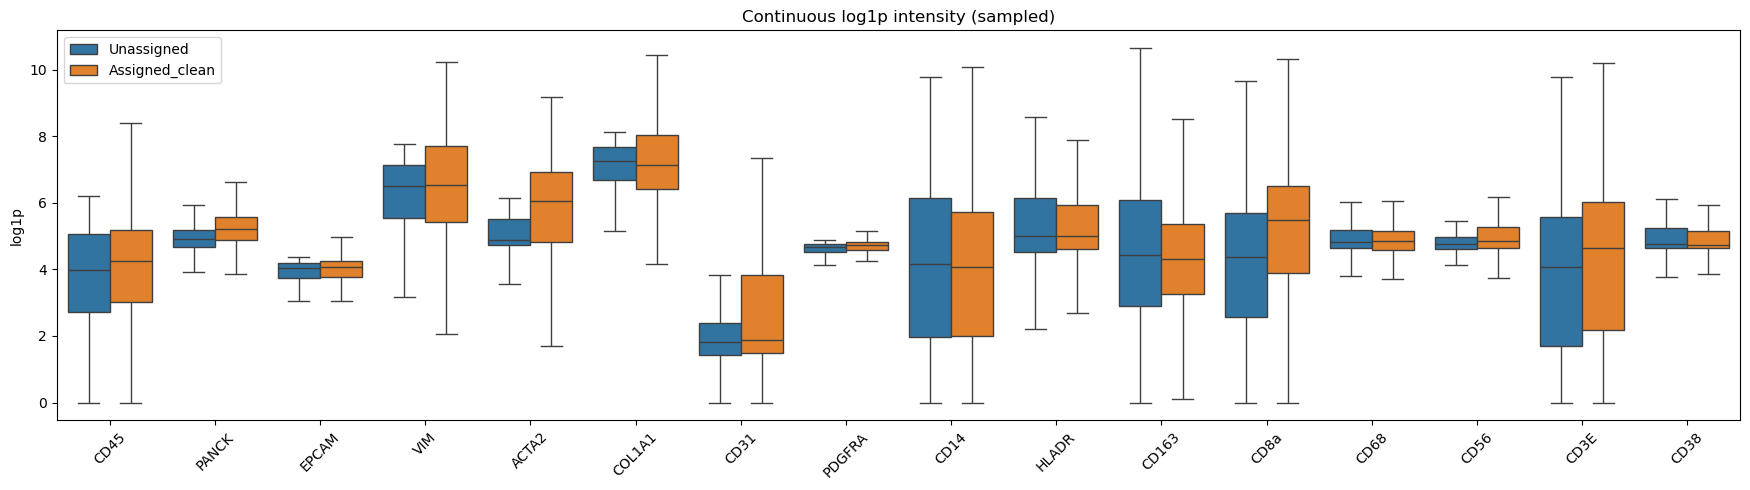

In [9]:
# Violin / box for a few lineage anchors + any markers with high Unassigned positivity
ANCHOR_MARKERS = ["CD45", "PANCK", "EPCAM", "VIM", "ACTA2", "COL1A1", "CD31", "PDGFRA"]
high_un_markers = pos_tbl.index[pos_tbl["Unassigned"] >= 0.05].tolist()
plot_markers = list(dict.fromkeys(
    [m for m in ANCHOR_MARKERS if m in markers] + high_un_markers[:8]
))

rows = []
rng = np.random.default_rng(0)
MAX_SAMPLE = 8000  # keep plotting tractable

for group_name, mask in [("Unassigned", mask_unassigned), ("Assigned_clean", mask_assigned)]:
    idx = np.flatnonzero(mask)
    if len(idx) > MAX_SAMPLE:
        idx = rng.choice(idx, size=MAX_SAMPLE, replace=False)
    for m in plot_markers:
        j = markers.index(m)
        vals = logX[idx, j]
        rows.append(pd.DataFrame({"marker": m, "group": group_name, "log1p": vals}))

plot_long = pd.concat(rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(max(10, 1.1 * len(plot_markers)), 5))
sns.boxplot(
    data=plot_long,
    x="marker",
    y="log1p",
    hue="group",
    ax=ax,
    showfliers=False,
    order=plot_markers,
)
ax.set_title("Continuous log1p intensity (sampled)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="")
fig.tight_layout()
plt.show()

## 7. Quick takeaways checklist

After running the cells above, fill in:

- [ ] What % of Unassigned are binary all-negative (`(none)` pattern)?
- [ ] Which markers (if any) are still frequently positive in Unassigned?
- [ ] Do top patterns look like missing rules, or weak/noisy signal?
- [ ] Do continuous intensities sit near background for Unassigned?

**Next:** Artifact_Spillover — break down by which spillover gate fired and inspect those channel pairs (binary + continuous).

---

## 8. Artifact_Spillover (placeholder)

To add next:
1. Recount which spillover gate each cell hit (`CD45+PANCK`, `CD45+CD31`, `PANCK+CD31`, `CD3E+CD20`)
2. Per-gate continuous intensity scatter / 2D density
3. Ask whether doubles are far above threshold (true co-detection) or hugging the cutoff